# <center> <b>Cover Page</b> </center>

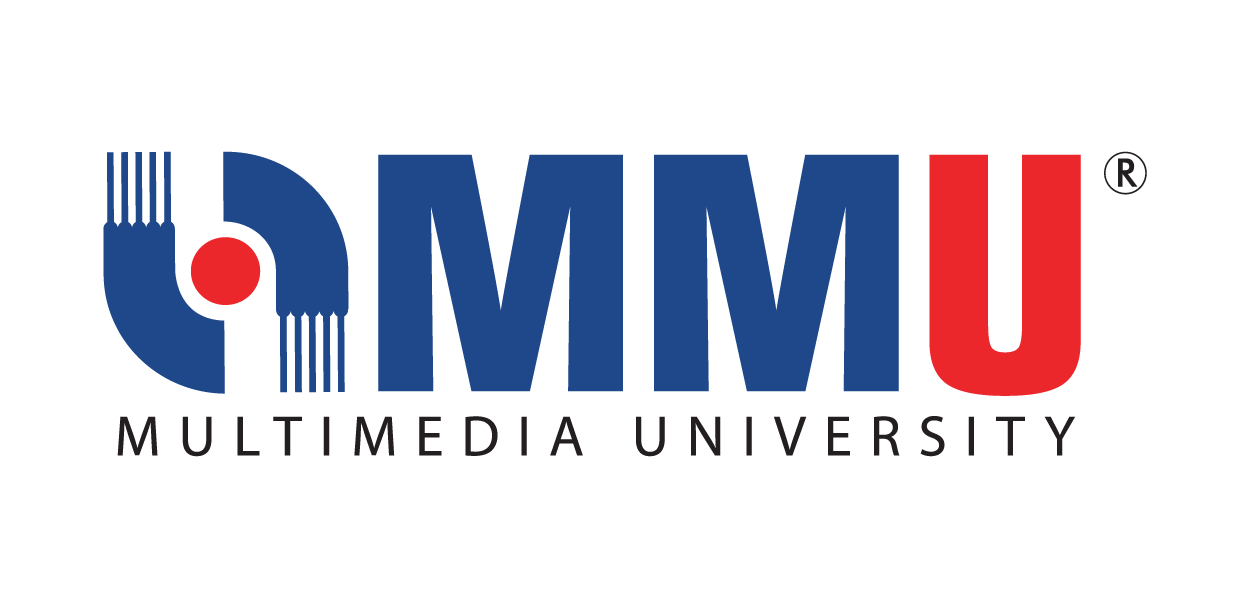

<center> <h2><b>Course Code</b> : </h2>  </center>
<center> <h2><b>Course Name</b> : Machine Learning</h2>  </center>
<center> <h2><b>Lecturer</b> : Prabha Kumaresan</h2>  </center>
<center> <h2><b>Academic Session</b> : March/April 2025</h2>  </center>
<center> <h2><b>Assessment Title</b> : Group Assignment</h2>  </center>




# <center><b>Introduction</b></center>

In the highly competitive landscape of short-term rental platforms such as Airbnb, accurately classifying property listings is essential for enhancing user experience, optimizing search functionality, and delivering relevant recommendations. Property type classification not only helps users filter accommodations that suit their preferences but also supports internal operations like pricing models, market analysis, and inventory categorization.

Airbnb listings are described by a mix of structured and unstructured data, ranging from numerical attributes like price and number of bedrooms, to categorical fields like neighborhood and cancellation policy, and even text-based information such as amenities. However, due to data complexity, feature noise, and an imbalanced distribution of property types, building an effective classification model becomes a non-trivial task.

This project uses machine learning techniques to build and evaluate models that predict the correct property type for a given listing. By comparing the performance of various models, from traditional logistic regression to deep neural networks, the goal is to determine the most effective approach for handling real-world challenges such as class imbalance, high-dimensional input, and non-linear feature interactions.

---
# <center><b>Objective</b></center>

The objective of this project is to develop an effective machine learning model that can accurately classify Airbnb listings into their correct property types. The goal is to evaluate and compare multiple models, ranging from logistics regression to deep neural networks, in order to determine which approach best addresses the challenges of multiclass classification, imbalanced class distributions, and high-dimensional feature spaces. The final model should be capable of generalizing well to new data while maintaining strong performance across all property categories, including minority classes.

---
# <center><b>Problem Statement</b></center>

Airbnb offers many types of properties, like apartments, houses, and lofts, each with many different features. Manually organizing these listings into the correct property types can be time-consuming and inconsistent, especially with thousands of listings and new ones being added all the time.

To help solve this, we aim to build a machine learning model that can automatically predict the correct property type for each listing based on its features. This would improve how Airbnb listings are categorized, making it easier for users to search and filter results, and helping the platform offer better recommendations. However, the data has challenges like many different property categories, unbalanced data and a mix of numerical and text-based information.

---
# <center><b>Model(s) Used and Justification</b></center>

1. **Logistic Regression (Original)**: This baseline model was chosen for its simplicity and interpretability. It provides a solid starting point, particularly for benchmarking. However, due to its linear nature and sensitivity to class imbalance, it struggled to perform well on minority property types, leading to poor recall in underrepresented classes.
  
2. **Logistic Regression (Improved)**: In this version, high-dimensional features such as TF-IDF-encoded amenities were removed, focusing instead on structured numerical and categorical data. This led to better overall accuracy and improved model efficiency. However, recall, especially for rare classes, saw limited improvement, confirming the model’s continued limitations in handling imbalanced multiclass scenarios.

3. **Artificial Neural Network (ANN)**: A shallow neural network was introduced to capture non-linear relationships among features. The model included one hidden layer and was able to outperform logistic regression in identifying patterns that the linear model missed. However, its simplicity still limited its ability to generalize well across complex feature interactions.

4. **Deep Neural Network (DNN)**: The most complex model involved a deeper architecture with multiple hidden layers and dropout regularization to prevent overfitting. This model achieved the best performance across accuracy, precision, recall, and F1-score, particularly due to its capacity to learn hierarchical feature representations and better handle class imbalance through dense, nonlinear mappings.

---
# <center><b>Problem Formulation</b></center>

The goal of this project is to build a machine learning model that can automatically classify Airbnb listings into the correct property type based on various details provided in the listing. Each listing includes a mix of numerical information and categorical attributes.

This is a multiclass classification problem, meaning the model must choose from several possible property types, such as Apartment, House, Loft, and more. The challenge is to train a model that can make accurate predictions across all these classes, even when some property types appear much more frequently than others.

There are several difficulties in this task:

**Many classes**: The model needs to distinguish between a wide range of property types.

**Imbalanced data**: Some property types are rare in the dataset, which can lead to biased predictions if not handled properly.

**High-dimensional features**: Categorical variables like neighborhoods or room types, when encoded, can result in a large number of input features.

**Non-linear relationships**: The relationship between features and the property type may not be straightforward, so more complex models may be needed.

Each model is evaluated based on its ability to correctly classify listings, especially for less common property types.

---
# <center><b>Data Preprocessing</b></center>

The dataset underwent several preprocessing steps:

1. **Feature Selection**: Clean and structured features were selected for modeling. High-dimensional or noisy features like 'amenities' were excluded in later experiments to simplify the model and improve performance.

2. **Encoding and Scaling**: Categorical features were transformed using one-hot encoding, while numerical features were standardized using StandardScaler to ensure consistent scale across inputs. The target variable was encoded using LabelEncoder to convert property types into numeric labels.

3. **SMOTE**: Balancing the classes in the training data to improve the performance of your machine learning model, especially when dealing with imbalanced datasets. By generating synthetic samples for the minority class, the model learn better and make more accurate predictions.

4. **Train-Test Split**: The dataset was split into training and testing sets using stratified sampling to preserve the class distribution, ensuring fair evaluation.

---
# <center><b>Model Development</b></center>

The **Logistic Regression** models were implemented using **Scikit-Learn’s** Pipeline functionality to seamlessly integrate preprocessing and training steps. Hyperparameters such as regularization strength and iteration limits were fine-tuned for better performance.

The **Artificial Neural Network (ANN)** and **Deep Neural Network (DNN)** models were implemented using **PyTorch**, offering more flexibility and control over the model architecture. The ANN included a single hidden layer, while the DNN was deeper with multiple hidden layers, ReLU activations, and dropout to combat overfitting. These networks allowed the model to learn non-linear interactions that logistic regression could not capture.

# ***Disclaimer***

Please note that while every effort has been made to ensure reproducibility through fixed random seeds and consistent model configurations, results such as loss values, accuracy, precision, recall, and other performance metrics may still vary slightly across different machines.
These differences typically result in minor fluctuations in model performance and are not indicative of bugs or incorrect implementations. The overall trends and conclusions drawn from the model remain valid and consistent.

# ***Abbreviation***

- listings: original/raw dataset.
- filtered_listings: merged property_type class dataset
- rare_classes: property_type with count lower than 5

# **1. IMPORTING LIBRARIES**

This section of the code is used to show the libraries that are imported for the assignment.

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from torch.utils.data import TensorDataset, DataLoader

# **2. LOADING DATASET**

This section of the code is used to load the dataset given.  

Below we are reading the .csv files **(calendar.csv , listings.csv , reviews.csv)** into a Pandas DataFrame **(calendar , listings , reviews)** using read_csv() function in Pandas.

In [43]:
calendar = pd.read_csv('calendar.csv')
listings = pd.read_csv('listings.csv')
reviews = pd.read_csv('reviews.csv')

The Pandas head() method is used to return top 5 rows of data frame, **"reviews".**

In [44]:
reviews.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,1178162,4724140,2013-05-21,4298113,Olivier,My stay at islam's place was really cool! Good...
1,1178162,4869189,2013-05-29,6452964,Charlotte,Great location for both airport and city - gre...
2,1178162,5003196,2013-06-06,6449554,Sebastian,We really enjoyed our stay at Islams house. Fr...
3,1178162,5150351,2013-06-15,2215611,Marine,The room was nice and clean and so were the co...
4,1178162,5171140,2013-06-16,6848427,Andrew,Great location. Just 5 mins walk from the Airp...


The Pandas head() method is used to return top 5 rows of data frame, **"calendar".**

In [45]:
calendar.head()

,listing_id,date,available,price
0,12147973,2017-09-05,f,NaN
1,12147973,2017-09-04,f,NaN
2,12147973,2017-09-03,f,NaN
3,12147973,2017-09-02,f,NaN
4,12147973,2017-09-01,f,NaN


The Pandas head() method is used to return top 5 rows of data frame, **"listings".**

In [46]:
listings.head()

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,12147973,https://www.airbnb.com/rooms/12147973,20160906204935,2016-09-07,Sunny Bungalow in the City,"Cozy, sunny, family home. Master bedroom high...",The house has an open and cozy feel at the sam...,"Cozy, sunny, family home. Master bedroom high...",none,"Roslindale is quiet, convenient and friendly. ...",...,NaN,f,NaN,NaN,f,moderate,f,f,1,NaN
1,3075044,https://www.airbnb.com/rooms/3075044,20160906204935,2016-09-07,Charming room in pet friendly apt,Charming and quiet room in a second floor 1910...,Small but cozy and quite room with a full size...,Charming and quiet room in a second floor 1910...,none,"The room is in Roslindale, a diverse and prima...",...,9.0,f,NaN,NaN,t,moderate,f,f,1,1.30
2,6976,https://www.airbnb.com/rooms/6976,20160906204935,2016-09-07,Mexican Folk Art Haven in Boston,"Come stay with a friendly, middle-aged guy in ...","Come stay with a friendly, middle-aged guy in ...","Come stay with a friendly, middle-aged guy in ...",none,The LOCATION: Roslindale is a safe and diverse...,...,10.0,f,NaN,NaN,f,moderate,t,f,1,0.47
3,1436513,https://www.airbnb.com/rooms/1436513,20160906204935,2016-09-07,Spacious Sunny Bedroom Suite in Historic Home,Come experience the comforts of home away from...,Most places you find in Boston are small howev...,Come experience the comforts of home away from...,none,Roslindale is a lovely little neighborhood loc...,...,10.0,f,NaN,NaN,f,moderate,f,f,1,1.00
4,7651065,https://www.airbnb.com/rooms/7651065,20160906204935,2016-09-07,Come Home to Boston,"My comfy, clean and relaxing home is one block...","Clean, attractive, private room, one block fro...","My comfy, clean and relaxing home is one block...",none,"I love the proximity to downtown, the neighbor...",...,10.0,f,NaN,NaN,f,flexible,f,f,1,2.25


The Pandas .columns attribute is used to return column names of **"reviews".**

In [47]:
reviews.columns

Index(['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments'], dtype='object')

The Pandas .columns attribute is used to return column names of **"calendar".**

In [48]:
calendar.columns

Index(['listing_id', 'date', 'available', 'price'], dtype='object')

The Pandas .columns attribute is used to return column names of **"listings".**

In [49]:
listings.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary',
       'space', 'description', 'experiences_offered', 'neighborhood_overview',
       'notes', 'transit', 'access', 'interaction', 'house_rules',
       'thumbnail_url', 'medium_url', 'picture_url', 'xl_picture_url',
       'host_id', 'host_url', 'host_name', 'host_since', 'host_location',
       'host_about', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url',
       'host_picture_url', 'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'street',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'city', 'state', 'zipcode', 'market',
       'smart_location', 'country_code', 'country', 'latitude', 'longitude',
       'is_location_exact', 'property_type', 'room_type', 'accommodates',
       'bathrooms',

# **3. DATA PREPROCESSING**

In this section of codes, we will be designing our data preprocessing to transform raw data into a format suitable for training and deploying models.  

Before we drop the irrelevant columns, we determine which columns are irrelevant to our data processing and analysis and list it down under **"irrelevant_cols"**. After, we drop the irrelevant columns from listings and create a new version of listings without the irrelevant columns. The **"errors='ignore'"** provides a way to bypass errors and continue execution.

In [50]:
# Drop irrelevant columns
irrelevant_cols = [
    'id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary', 'space',
    'description', 'neighborhood_overview', 'notes', 'transit', 'access', 'interaction',
    'house_rules', 'thumbnail_url', 'medium_url', 'picture_url', 'xl_picture_url',
    'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
    'host_thumbnail_url', 'host_picture_url', 'street', 'zipcode', 'market', 'country_code',
    'country', 'calendar_updated', 'calendar_last_scraped', 'license', 'jurisdiction_names']

listings = listings.drop(columns=irrelevant_cols, errors='ignore')

The code below is used to clean and preprocess a Pandas DataFrame called listings.

First, it handles numerical columns **(bathrooms, bedrooms, beds, price, review_scores_rating)** by replacing non-numeric characters with empty strings, converting the columns to floating-point numbers, and then imputing missing values using the median of each column. The method used for this is called imputation (Median Imputation).   

Next, it handles categorical columns **(host_response_time, host_is_superhost, cancellation_policy)** by filling missing values with the mode of each column. Similar to the method we used in handling numerical column, this is also imputation (Mode Imputation).  

Finally, it drops the **square_feet** column, as it's assumed to have more than 50% missing data. The function returns the cleaned DataFrame. The process ensures that missing data doesn't negatively impact further analysis or modeling, by strategically replacing missing values with reasonable estimates.

In [51]:
# Handle missing values
def handle_missing_data(listings):
    # Numerical columns: Impute with median
    num_cols = ['bathrooms', 'bedrooms', 'beds', 'price', 'review_scores_rating']
    for col in num_cols:
        listings[col] = listings[col].replace('[^0-9.]', '', regex=True).astype(float)  # Clean price if needed
        listings[col] = listings[col].fillna(listings[col].median())

    # Categorical columns: Impute with mode
    cat_cols = ['host_response_time', 'host_is_superhost', 'cancellation_policy']
    for col in cat_cols:
        listings[col] = listings[col].fillna(listings[col].mode()[0])

    # Drop columns with >50% missing data (e.g., 'square_feet')
    listings = listings.drop(columns=['square_feet'], errors='ignore')

    return listings

listings = handle_missing_data(listings)


The code below is used to define the features and target of X and y respectively.  

The X (features) values we determined are the columns **'neighbourhood_cleansed', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'price', 'amenities', 'cancellation_policy', 'review_scores_rating'**.  

The y (target) value we determined is the column **'property_type'**.  

In [52]:
# Define features (X) and target (y)
target = 'property_type'
features = [
    'neighbourhood_cleansed', 'room_type', 'accommodates', 'bathrooms', 'bedrooms',
    'price', 'amenities', 'cancellation_policy', 'review_scores_rating'
]

X = listings[features]
y = listings[target]


The code below is used to encode our **target (y)**  to transform your categorical target variable into a numerical representation, making it compatible with machine learning algorithms, allowing the machine to learn from the data and make predictions.

In [53]:
# Encode the target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

The code below is used to check for **"listings"** class distribution.  

We use **.value_counts()** to count the number of occurrences of each unique value in a **"listings"**. Then we print out all the class distribution in **"listings"** using **"print()"** because class distribution is crucial for understanding and addressing potential biases in models.

In [54]:
# Check class distribution
class_counts = listings['property_type'].value_counts()
print("Class distribution:\n", class_counts)

Class distribution:
 property_type
Apartment          2612
House               562
Condominium         231
Townhouse            54
Bed & Breakfast      41
Loft                 39
Other                17
Boat                 12
Villa                 6
Entire Floor          4
Dorm                  2
Guesthouse            1
Camper/RV             1
Name: count, dtype: int64


**Handling Property Type distribution imbalance**

The code below is used to filter **'listings'**. The **'min_sample'** is 10 as a category needs to appear at least 10 times in the dataset to be considered valid. 

**class_counts** is an array that contains the counts of each unique value in the **'property_type'** column. **'class_counts >= min_samples'** is used to compare which class counts are greater than or equal to **min_samples**. **'.index'** is used to extract the index of the filtered **class_counts**.

**'listings['property_type'].isin(valid_classes)'** is used to check whether the value in the 'property_type' column is present in the valid_classes and create a Boolean series. 

In [55]:
min_samples = 10
valid_classes = class_counts[class_counts >= min_samples].index
listings_filtered = listings[listings['property_type'].isin(valid_classes)]

**.copy()** is used to create a clean copy of the filtered DataFrame.

**rare_classes** is a group of classes that rarely appeared in **'property_type'**.

**.loc** allows us to select data from the filtered listings. After, we merge all of the rare classes into **'property_type'** under **'Other'**

In [56]:
listings_filtered["property_type"].unique()

array(['House', 'Apartment', 'Condominium', 'Bed & Breakfast',
       'Townhouse', 'Loft', 'Boat', 'Other'], dtype=object)

In [57]:
# Create a clean copy of the filtered DataFrame to avoid chained assignments
listings_filtered = listings_filtered.copy()

# Merge rare classes into "Other"
rare_classes = ['Villa', 'Entire Floor', 'Dorm', 'Guesthouse', 'Camper/RV']
listings_filtered.loc[
    listings_filtered['property_type'].isin(rare_classes), 'property_type'
] = 'Other'

The code below is used to encode our **target (y)** using the newly filtered listings. 

After that, we split the features (X) into training and testing sets using **train_test_split**, with stratification (stratify=y) to maintain the class distribution in both sets.

In [58]:
# Encode the target variable
le = LabelEncoder()
y = le.fit_transform(listings_filtered['property_type'])

# Split data (stratify safely now)
X = listings_filtered[features]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

This code is used to calculate class weights, which are used to address class imbalance in the data. The output will return an array of class weights, where each weight corresponds to a unique class in the data.  

**'class_weight='balanced'''** is used to calculate class weights based on the inverse of the class frequencies. 
**'classes=np.unique(y_train)'** provides the unique class labels present in the training data **(y_train)**.

In [59]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

The code below is used to check for **"listings_filtered"** class distribution for the column **'property_type'**.  

We use **.value_counts()** to count the number of occurrences of each unique value in a **"property_type"**. Then we print out all the class distribution in **"property_type"** using **"print()"**.

In [60]:
# Check class distribution
class_counts = listings_filtered['property_type'].value_counts()
print("Class distribution (NEW):\n", class_counts)

Class distribution (NEW):
 property_type
Apartment          2612
House               562
Condominium         231
Townhouse            54
Bed & Breakfast      41
Loft                 39
Other                17
Boat                 12
Name: count, dtype: int64


This code generates two count plots to visualize the distribution of **'property_types'.**

The first plot is used to show the raw data before we prep the data using the previous codes. The second plot is used to show the data after filtering and merging using the previous snippets of codes. 

The plots use seaborn's countplot to show the counts of each property type, ordered by frequency to make it easier to see the most and least common types.   

This visual comparison helps us understand the impact of data preprocessing steps affected the proportions of different categories within the dataset.

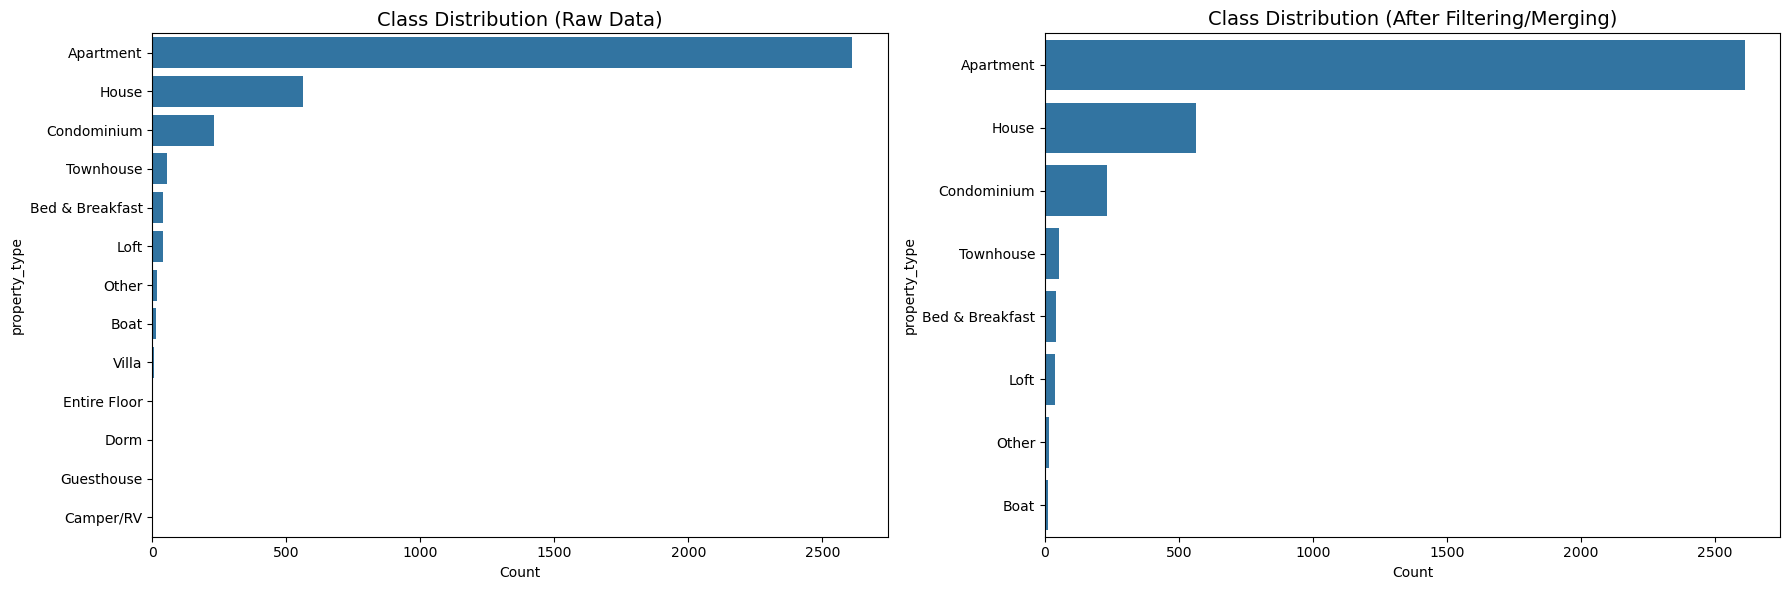

In [61]:
# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Before filtering
sns.countplot(data=listings, y='property_type', ax=axes[0], order=listings['property_type'].value_counts().index)
axes[0].set_title('Class Distribution (Raw Data)', fontsize=14)
axes[0].set_xlabel('Count')

# After filtering/merging
sns.countplot(data=listings_filtered, y='property_type', ax=axes[1], order=listings_filtered['property_type'].value_counts().index)
axes[1].set_title('Class Distribution (After Filtering/Merging)', fontsize=14)
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

This code analyses the **'amenities'** column in your dataset.

**'all_amenities = []'** initialises an empty list to store all individual amenities. After, we have a for loop that iterates through the **'amenities'** column of the **listings_filtered** DataFrame and splits each string in the **'amenities'** column into a list of individual amenities, using the comma (,) as a delimiter. **.strip()** removes any leading or trailing whitespace from each amenity and **all_amenities.extend()** adds the cleaned amenities to the **all_amenities** list.

After, **'amenity_counts'** uses the Counter class from the collections module to count the occurrences of each unique amenity in the **all_amenities** list. Next, **'amenity_counts.most_common(10)'** gets the 10 most frequent amenities and their counts from the **amenity_counts** counter and creates a Pandas DataFrame from the top 10 amenities and their counts, with columns named **'Amenity'** and **'Count'** using **pd.DataFrame**.

To plot, the code uses a bar plot to display the most frequent amenities found in the data. The plot shows each of the top 10 amenities as a bar, and the height of each bar corresponds to how many times that amenity appears in the dataset. This helps us understand which amenities are most frequently associated with the properties in your dataset.

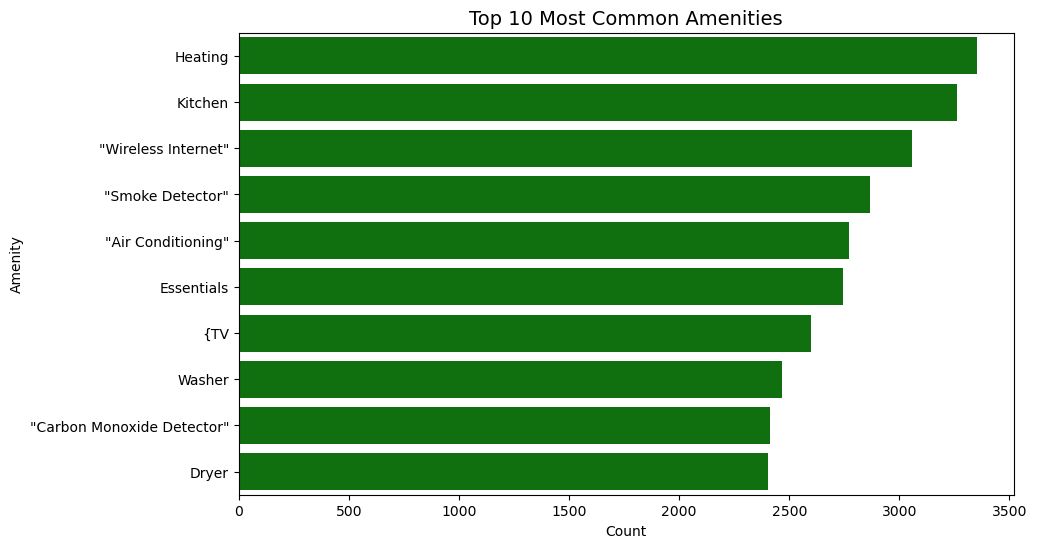

In [62]:
# Split amenities into individual items and count frequencies
all_amenities = []
for amenities_list in listings_filtered['amenities'].str.split(','):
    all_amenities.extend([amenity.strip() for amenity in amenities_list])

amenity_counts = Counter(all_amenities)
top_amenities = pd.DataFrame(amenity_counts.most_common(10), columns=['Amenity', 'Count'])

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_amenities, x='Count', y='Amenity', color = "green", legend=False)
plt.title('Top 10 Most Common Amenities', fontsize=14)
plt.show()

This code prepares the data for a machine learning model by selecting features **('neighbourhood_cleansed', 'room_type', 'accommodates', 'bathrooms','bedrooms', 'price', 'amenities', 'cancellation_policy', 'review_scores_rating')**, handling different data types (such as numerical, categorical, and text), scaling numerical features, encoding categorical and text features, and splitting the data into training and testing sets.

For Numerical Features, **StandardScaler()** is applied to the numerical features **('accommodates', 'bathrooms', 'bedrooms', 'price', 'review_scores_rating'). StandardScaler** scales these features to have a mean of 0 and a standard deviation of 1.

For Categorical Features, **OneHotEncoder()** is applied to the categorical features **('room_type', 'cancellation_policy', 'neighbourhood_cleansed')**. **OneHotEncoder** converts these categorical variables into a numerical format by creating binary columns for each category. The **handle_unknown='ignore'** argument is used to deal with any categories in the test set that were not present in the training set.

For Text Features, **TfidfVectorizer(max_features=100)** is applied to the **'amenities'** column. **TfidfVectorizer** converts the text data in the **'amenities'** column into numerical data using the **TF-IDF (Term Frequency-Inverse Document Frequency)** method. It also limits the number of features to the top 100 most frequent words.

**X_preprocessed = preprocessor.fit_transform(X)** line applies the transformations defined in the preprocessor to the input data **X**. The **fit_transform** method first "fits" the transformers and learns the necessary parameters, such as the mean and standard deviation for **StandardScaler** or the vocabulary for **TfidfVectorizer** and then transforms the data. The next line converts the output of the **ColumnTransformer** to a NumPy array. This is often necessary for compatibility with some machine learning models.

After that, we do label encoding which is a process in machine learning that converts categorical data into numerical format by assigning each unique category a unique integer. First, we create a **LabelEncoder** object, then we fit the **LabelEncoder** to the target variable **y** and transforms it into numerical labels. This step is essential because most machine learning models require numerical input for the target variable.

After that, we split the preprocessed data into training and testing sets. The **test_size** specifies that **20%** of the data will be used for testing. The next line ensures that the class distribution in the training and testing sets is the same as in the original dataset. This is important when dealing with imbalanced datasets. Lastly, we set a random seed for reproducibility using **random_state=42**.

In [63]:
features = [
    'neighbourhood_cleansed', 'room_type', 'accommodates', 'bathrooms',
    'bedrooms', 'price','amenities' ,'cancellation_policy', 'review_scores_rating'
]
X = listings_filtered[features]
y = listings_filtered['property_type']  # Already label-encoded

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), ['accommodates', 'bathrooms', 'bedrooms', 'price', 'review_scores_rating']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['room_type', 'cancellation_policy', 'neighbourhood_cleansed']),
    ('text', TfidfVectorizer(max_features=100), 'amenities')
])

X_preprocessed = preprocessor.fit_transform(X)
X_preprocessed = X_preprocessed.toarray() if hasattr(X_preprocessed, "toarray") else X_preprocessed

le = preprocessing.LabelEncoder()
y_encoded = le.fit_transform(y)

X_trainorig, X_testorig, y_trainorig, y_testorig = train_test_split(
    X_preprocessed, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)


This code below uses **SMOTE (Synthetic Minority Over-sampling Technique)** which is a data preprocessing technique and it is crucial for balancing the classes in the training data to improve the performance of your machine learning model, especially when dealing with imbalanced datasets. By generating synthetic samples for the minority class, we help the model learn better and make more accurate predictions.

**smote = SMOTE(random_state=42)** initializes the SMOTE object, which is used to generate synthetic samples for the minority class in your dataset. The next line applies SMOTE to the preprocessed feature set **(X_preprocessed)** and the encoded target variable **(y_encoded)**. It generates new synthetic examples for the minority class, effectively balancing the class distribution. 

The next segment of code splits the resampled data. **X_train, X_test, y_train, y_test = train_test_split** line splits the resampled dataset into training and testing sets.
**test_size=0.2** specifies that **20%** of the data will be used for testing. **stratify=y_resampled** ensures that the class distribution in the training and testing sets reflects the balanced distribution created by SMOTE. **random_state=42** sets a random seed for reproducibility, ensuring that the split can be replicated.

In [64]:
# Apply SMOTE to balance classes in training data only
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_preprocessed, y_encoded)

# Split the resampled data
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# **4. CREATING MACHINE LEARNING MODEL**

This next section we will be creating some machine learning algorithms that is best suited for our goals and give us our desired outcome. 

Some of the machine learning model we will be using are:
1. Logistic Regression Original Model – included amenities as TF-IDF features
2. Logistic Regression Improved Model – removed amenities, using only structured numeric and categorical data
3. Deep Neural Network (Feedforward Neural Network)
4. Artificial Neural Network

#### Formula for the Evaluations and Explaination

**Accuracy** is determined by dividing the total number of input samples by the number of accurate predictions. It is important for assessing a classification model's performance, giving a brief overview of the model's accuracy in making predictions.

$$
Accuracy = \frac{True Positives}{True Positives + False Positives + True Negatives + False Negatives}
$$


**Precision** is a ratio of correctly predicted positive instance to the total of positive instances and it indicates the proportion of positive predictions that the model is truly right.

$$
Precision = \frac{True Positives}{True Positives + False Positives}
$$


**Recall** is the ratio of correctly predicted positive instances to the total actual positive instances. It gauges how well every pertinent positive example is captured by the model.

$$
Recall = \frac{True Positives}{True Positives + False Negatives}
$$


**F1-Score** is is a harmonic mean between recall and precision. The range of F1-Score is **[0,1]**. The precision (number of instances properly classified) and reliability (number of instances missed) of our classifier are typically shown by this parameter.

$$
F1-Score = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

### Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for classification problems. The code uses Logistic Regression model to classify property types. 

For the first line of code, the model is created with a maximum of 1000 iterations **(max_iter=1000)**, using the lbfgs solver **(solver='lbfgs')** and a fixed random state for reproducibility **(random_state=42)**. The model then uses **logreg.fit(X_train, y_train)** to train on a resampled version of the training data to help address class imbalance. After training, the model uses **y_pred = logreg.predict(X_testorig)** to predict property types on the original test set. The model’s performance is evaluated using three metrics which is **accuracy, a detailed classification report, and a confusion matrix.**

In [65]:
# create model
logreg = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)

# train model on resampled training data
logreg.fit(X_train, y_train)

# Predict on the test set
y_pred = logreg.predict(X_testorig)


Classification Report:
                  precision    recall  f1-score   support

      Apartment       0.93      0.48      0.64       523
Bed & Breakfast       0.18      0.75      0.29         8
           Boat       0.18      1.00      0.31         2
    Condominium       0.18      0.52      0.26        46
          House       0.55      0.58      0.56       113
           Loft       0.08      0.75      0.15         8
          Other       0.43      1.00      0.60         3
      Townhouse       0.11      0.64      0.19        11

       accuracy                           0.51       714
      macro avg       0.33      0.71      0.37       714
   weighted avg       0.79      0.51      0.58       714



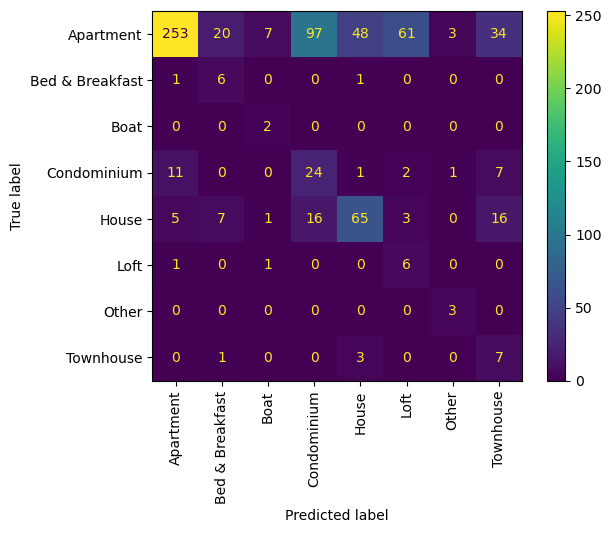

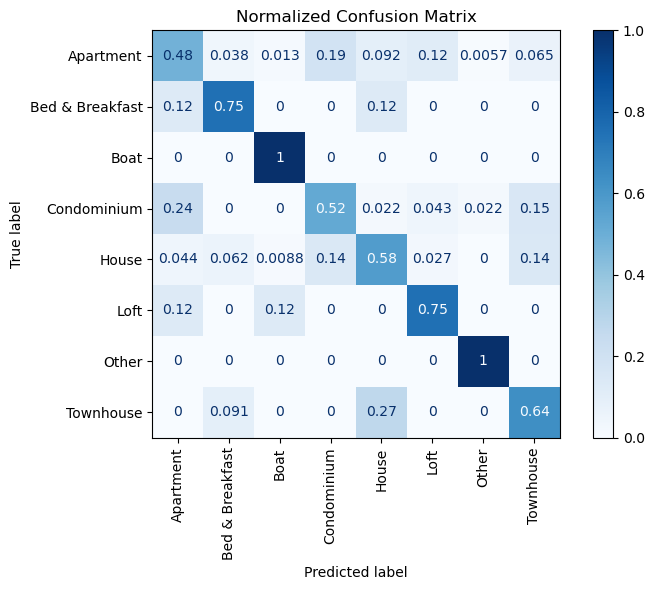

In [66]:
# Evaluate the model
print("\nClassification Report:\n", classification_report(y_testorig, y_pred, target_names=le.classes_))

# Plot confusion matrix
cm = confusion_matrix(y_testorig, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=90)

# normalize the matrix by row
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# plot the normalized confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', xticks_rotation=90, ax=ax)
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

### Why Normalized Confusion Matrices?
Normalized confusion matrices are essential in classification tasks involving imbalanced datasets, as they convert raw prediction counts into relative proportions by dividing each row by the total number of true instances for that class. This transformation makes the matrix class-size invariant, enabling fairer comparison between dominant and minority classes. The diagonal values in a normalized confusion matrix represent the recall for each class, or the proportion of correctly predicted instances, while the off-diagonal values indicate misclassification rates, showing which classes are commonly confused. 

In situations where one class, such as "Apartment," appears far more frequently than others, raw confusion matrices can be misleading because they are dominated by the most common class and obscure poor performance on less-represented categories. Normalized matrices overcome this by clearly illustrating model behavior across all classes, making them especially useful for diagnosing bias and evaluating generalization in models like Logistic Regression, ANN, or DNN.

### Logistic Regression – Initial Evaluation & Insights

Logistic Regression was the first model applied to classify Airbnb property types using features such as `room_type`, `bedrooms`, `price`, `review_scores_rating`, and more , including a TF-IDF representation of `amenities`.

The model achieved an **overall accuracy of 0.51** and a **macro-average F1-score of just 0.37**. While these numbers indicate moderate predictive power, a deeper analysis reveals important insights:

---

#### Key Highlights from Classification Report:
- **"Apartment"** remains the dominant class, with a **precision of 0.93**, but only a **recall of 0.48**.
- This indicates the model **predicts “Apartment” very confidently**, but **misses more than half** of actual "Apartment" listings.
- Several minority classes such as **"Boat", "Loft", and "Townhouse"** achieved recall scores above 0.60, but with **very low precision** (0.08–0.18), reflecting **many false positives**.
- **Macro-average precision: 0.33**, **Macro-average recall: 0.71**, showing that while the model can find a variety of classes, it's not precise in doing so.

---

#### Confusion Matrix Interpretation:
The confusion matrix reveals substantial **confusion among similar or low-representation classes**:
- Many **"House"** listings were misclassified as **"Apartment"**, **"Condominium"**, or **"Townhouse"**.
- **"Apartment"** listings were frequently confused with **"Condominium"**, **"House"**, and even **"Loft"**.
- Minority classes like **"Boat"**, **"Loft"**, and **"Other"** had very small support, making it difficult for a linear model to form clear boundaries.

**Normalized Confusion Matrix**  

This model demonstrates moderate but uneven classification performance. The recall for the Apartment class is **0.48**, meaning only **48%** of actual Apartment listings were correctly predicted. Misclassifications from Apartment include **19%** as Condominium and **12%** as House. Bed & Breakfast achieves a recall of **0.75**, but **12%** of its listings are incorrectly predicted as House. The Boat class is perfectly classified with a recall of **1.00**, though this may be due to a small sample size. Condominium has a recall of **0.52**, with **24%** of its listings misclassified as Apartment and **15%** as Townhouse. House achieves **0.58** recall, with noticeable confusion toward Apartment **(14%)** and Townhouse **(14%)**. Loft is correctly predicted **75%** of the time, while **12%** is misclassified as Apartment and another **12%** as Boat. Other achieves perfect recall. Townhouse reaches a recall of **0.64** but is misclassified as House **27%** of the time. Overall, the model captures dominant patterns but struggles to clearly separate similar housing types.

---

### Reason for trying to improve model
The inclusion of the `amenities` column as TF-IDF vectors added **many sparse features** to the dataset, which may have overwhelmed Logistic Regression. Being a **linear classifier**, Logistic Regression tends to perform poorly in high-dimensional, non-linearly separable problems.

> **Next**, we will explore an **improved version of Logistic Regression** by **removing the `amenities` feature**, to evaluate whether simpler, structured data leads to better generalization and balanced class performance.


### Improved Logistic Regression (Without `amenities`)

In this section, we improve our Logistic Regression model by removing the `amenities` feature, which was previously encoded using TF-IDF and introduced high dimensionality. This simplification aims to:
- Reduce feature sparsity
- Lower model complexity
- Improve generalization to minority classes

We focus only on structured numerical and categorical features to assess whether the model can perform better with cleaner data.

This code section prepares the dataset for training a machine learning model by selecting a subset of clean and structured features from a larger Airbnb listings dataset. The list **features_lr** defines the specific features to be used as inputs **(X)** for the model. These features include categorical variables such as **'neighbourhood_cleansed', 'room_type', and 'cancellation_policy'**, as well as numerical variables like **'accommodates', 'bathrooms', 'bedrooms', 'price', and 'review_scores_rating'**. Notably, complex and unstructured features such as **'amenities'** have been excluded to keep the model input clean and interpretable. The input feature **matrix X_lr** is then created by selecting these columns from the filtered DataFrame **listings_filtered**. The target variable **y_lr** is defined as the **'property_type'** column, which the model will aim to predict. This setup is typically used for a classification task where the model learns to predict the type of property based on the selected features.

In [67]:
# Select clean, structured features (amenities dropped)
features_lr = [
    'neighbourhood_cleansed',
    'room_type',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'price',
    'cancellation_policy',
    'review_scores_rating'
]

X_lr = listings_filtered[features_lr]
y_lr = listings_filtered['property_type']

The code defines a preprocessing pipeline named **preprocessor_lr** using **ColumnTransformer** to handle both numerical and categorical features in preparation for model training. Numerical features such as **'accommodates', 'bathrooms', 'bedrooms', 'price', and 'review_scores_rating'** are standardized using **StandardScaler** to normalize their scales, while categorical features like **'room_type', 'cancellation_policy', and 'neighbourhood_cleansed'** are encoded using **OneHotEncoder** with **handle_unknown='ignore'** to manage any unseen categories during testing or inference.

In [68]:
preprocessor_lr = ColumnTransformer(transformers=[
    ('num', StandardScaler(), ['accommodates', 'bathrooms', 'bedrooms', 'price', 'review_scores_rating']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['room_type', 'cancellation_policy', 'neighbourhood_cleansed'])
])

In this section, the target **variable y_lr**, which represents the property type, is transformed into numerical labels using **LabelEncoder**, resulting in **y_encoded_lr**. The dataset is then split into training and testing sets using **train_test_split**, with 80% of the data used for training and 20% for testing. The stratify parameter ensures that the class distribution of **y_encoded_lr** is preserved across both sets, and a fixed **random_state** is used for reproducibility.

In [69]:
le = LabelEncoder()
y_encoded_lr = le.fit_transform(y_lr)

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_encoded_lr, test_size=0.2, stratify=y_encoded_lr, random_state=42
)

In this section, a Pipeline named **logreg_pipeline** is constructed to combine preprocessing and model training in a single streamlined process. The pipeline first applies the defined preprocessing steps and then fits a **LogisticRegression** model with a maximum of **1000** iterations, a regularization strength **C=0.1**, and a fixed random seed for consistent results. The pipeline is then trained using the training set **X_train_lr** and **y_train_lr**, making it ready for evaluation or prediction on new data.

In [70]:
logreg_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=1000, C=0.1, random_state=42))
])

logreg_pipeline.fit(X_train_lr, y_train_lr)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['accommodates', 'bathrooms',
                                                   'bedrooms', 'price',
                                                   'review_scores_rating']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['room_type',
                                                   'cancellation_policy',
                                                   'neighbourhood_cleansed'])])),
                ('classifier',
                 LogisticRegression(C=0.1, max_iter=1000, random_state=42))])

                 precision    recall  f1-score   support

      Apartment       0.77      0.99      0.87       523
Bed & Breakfast       0.00      0.00      0.00         8
           Boat       0.00      0.00      0.00         2
    Condominium       0.00      0.00      0.00        46
          House       0.75      0.32      0.45       113
           Loft       0.00      0.00      0.00         8
          Other       0.00      0.00      0.00         3
      Townhouse       0.00      0.00      0.00        11

       accuracy                           0.77       714
      macro avg       0.19      0.16      0.16       714
   weighted avg       0.69      0.77      0.71       714



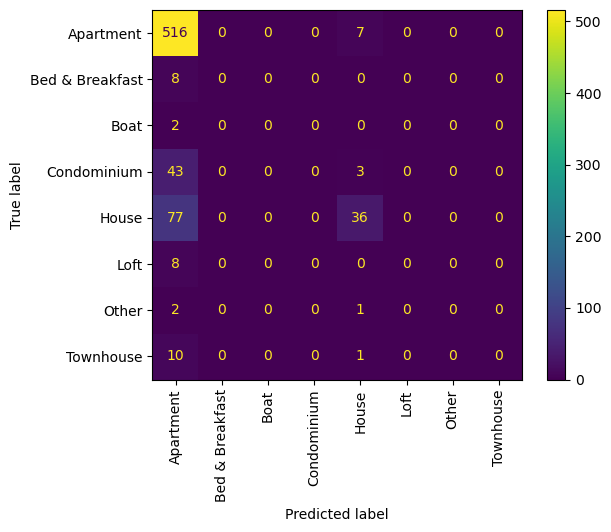

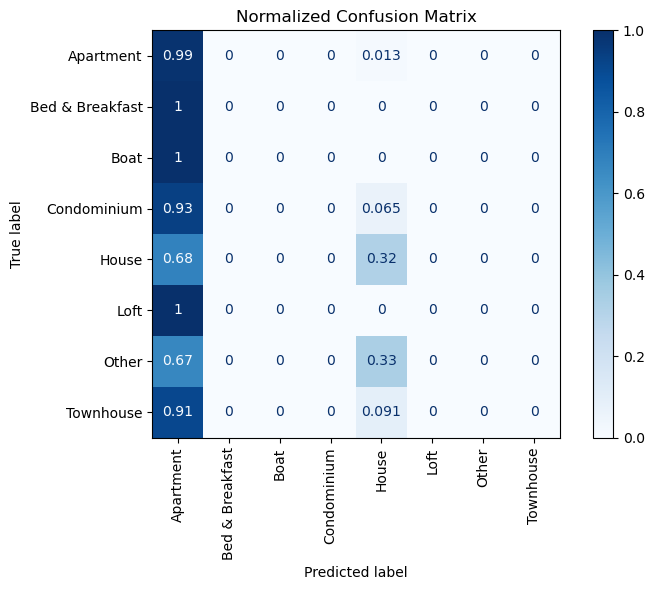

In [71]:
y_pred_lr = logreg_pipeline.predict(X_test_lr)

# Print evaluation
print(classification_report(y_test_lr, y_pred_lr, target_names=le.classes_, zero_division = 0))

# Plot confusion matrix
cm = confusion_matrix(y_test_lr, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=90)

# normalize the matrix by row
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# plot the normalized confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', xticks_rotation=90, ax=ax)
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

#### Key Highlights from Classification Report:
- The model shows high recall (0.99) and decent precision (0.77) for the "Apartment" class, resulting in a strong F1-score of 0.87.
- However, this comes at the cost of generalization, as the model tends to over-predict “Apartment” for many samples, regardless of their true class.
- Most other classes , including "Boat", "Loft", "Other", and "Townhouse" - scored zero on all evaluation metrics, reflecting complete failure in recognizing these categories.
- While the weighted F1-score is 0.71, the macro F1-score of 0.16 uncovers the severe disparity in per-class performance.
- The macro-average precision of 0.19 further confirms the model’s tendency to predict dominant classes only.

#### Confusion Matrix Interpretation:
- The raw and normalized confusion matrices show that the model is highly biased toward the "Apartment" label:
- Most listings , regardless of their actual label , are misclassified as "Apartment".
- For example, 68% of “House” listings and 93% of “Condominium” listings were incorrectly labeled as “Apartment.”
- Minority classes such as "Boat", "Loft", and "Other" received no correct predictions.

**Normalised Confusion Matrix**  

This version of logistic regression shows severe class imbalance. The model predicts Apartment with a high recall of **0.99**. However, this comes at the expense of other classes, which are frequently misclassified as Apartment. For instance, Condominium is predicted as Apartment **93%** of the time, with only **6.5%** classified correctly. House shows a recall of **0.32**, with **68%** misclassified as Apartment. Smaller classes such as Loft, Other, and Townhouse receive no correct predictions at all, as the model consistently outputs "Apartment" for them. While the high Apartment recall boosts overall accuracy, this matrix reveals poor generalization and extreme bias toward the dominant class(Overfitted), highlighting a major shortcoming in model fairness and usefulness for multiclass classification.

### Comparison: Original vs Improved Logistic Regression

We trained two versions of Logistic Regression to predict property types:

1. **Original Model** – included `amenities` as TF-IDF features
2. **Improved Model** – removed `amenities`, using only structured numeric and categorical data

---

#### Evaluation Summary:

| Metric           | Original Model | Improved Model |
| Accuracy         | 0.51           | **0.77**       |
| Macro Precision  | 0.33           | 0.19           |
| Macro Recall     | 0.71           | 0.16           |
| Macro F1-score   | 0.37           | 0.16           |
| Weighted F1-score| 0.58           | **0.71**       |

---

### Interpretation:

- **Accuracy was higher in the improved model** (0.77), but this came at a major cost:
  - The model became heavily biased toward the dominant class "Apartment"
  - Minority classes like "Boat", "Townhouse", "Loft" all had **0 precision and recall**
- The **original model** had **more balanced recall across classes**, especially for minority ones.
  - Despite lower accuracy, it **identified more classes correctly** to some extent.
- This shows that `amenities`, though sparse, provides useful context to distinguish between similar classes.

---

### Final Notes:

The improved model performs well **only in terms of raw accuracy**, which is misleading in multiclass imbalanced settings. The original model, although lower in accuracy, offers better **macro F1 and recall**, which are more informative for evaluating performance across all classes.

We will now move forward to evaluate more expressive models like **ANN and DNN**, which are designed to handle high-dimensional, nonlinear, and imbalanced classification tasks more effectively.

### Converting the train and test data into PyTorch formats

The code below transforms the preprocessed and split data into a format suitable for training and evaluating a PyTorch deep learning model. 

First, it converts the NumPy arrays **X_testorig, X_train, y_train, X_test, and y_test** into PyTorch tensors. **X_testorig, X_train** and **X_test** are converted to tensors of **float32** data type, while **y_train** and **y_test** are converted to tensors of **long** data type, which is appropriate for class labels. 

Then, it creates **TensorDataset** objects for both the training and testing sets. These datasets wrap the tensors and allow for easy access to the data and labels. Finally, it creates **DataLoader** objects for both the training and testing sets. The **DataLoader** handles batching, shuffling the training set, and parallel data loading, which are essential for efficient training of deep learning models. The **batch_size** is set to **64**, meaning that the data will be processed in batches of 64 samples. The **shuffle=True** argument for the training data loader shuffles the data at the start of each epoch, which helps to improve the model's generalization ability. The **shuffle=False** argument for the testing data loader means the data is not shuffled during testing.

In [72]:
# convert to tensors

X_testorig_tensor = torch.tensor(X_testorig, dtype=torch.float32)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


###  Artificial Neural Network (ANN)

In this section, we implement a shallow Artificial Neural Network (ANN) to classify Airbnb property types.

Unlike Logistic Regression, ANN is capable of modeling non-linear relationships, making it more suitable for handling:
- Class imbalance
- High-dimensional categorical data
- Subtle feature interactions

We begin with a single hidden layer model and evaluate its performance.

This code section defines the architecture of a shallow artificial neural network (ANN) model named **ShallowAirbnbNN** using the **PyTorch** library. This model is designed for a predictive task, such as regression or classification, depending on the context of the input and output data.

The model's architecture is constructed within the **ShallowAirbnbNN** class, which inherits from **nn.Module**, PyTorch’s base class for building neural network components. The constructor, **init**, initializes two fully connected linear layers which is **fc1 and fc2**. The first layer **(fc1)** maps the input features to a hidden layer with **64 neurons**. The second layer **(fc2)** maps the output of the hidden layer to the final output size, which could represent a single value or multiple class logits.

In the forward method, the input data is first passed through the **fc1** layer, followed by a **ReLU** activation function to introduce non-linearity. The activated output is then passed through the **fc2** layer, which produces the final output as raw logits.

After defining the architecture, an instance of the model can be created by specifying the input dimension **(input_size)**, which typically corresponds to the number of features in the training dataset, and the output dimension **(output_size)**, which depends on the number of regression targets or classification categories. The model can then be trained using appropriate loss functions and optimizers for the given task.

In [73]:
class ShallowAirbnbNN(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 64)  # Smaller hidden layer
        self.fc2 = nn.Linear(64, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x)) # activation
        return self.fc2(x) # raw logits

###  ANN Training Setup

We preprocess the data using the same `ColumnTransformer` used for the original Logistic Regression Model. Then, we train our ANN using CrossEntropyLoss and the Adam optimizer.

Training is done over 50 epochs.


This section of code defines and executes the training process for the **ShallowAirbnbNN** model using **PyTorch**. The training begins by setting a manual seed to ensure reproducibility. The model is initialized with the number of input features **(input_dim)** and output classes **(output_dim)** derived from the training data and label encoder. The loss function is specified as **CrossEntropyLoss**, which is suitable for multi-class classification tasks as it measures the difference between the predicted logits and the true class labels. The **Adam** optimizer is employed to update the model’s weights, with a learning rate of **0.0005** chosen to promote stable and gradual learning. The training loop is set to run for **50 epochs**, balancing learning progress and computational efficiency.

During each epoch, the model is switched to training mode using **ann_model.train()**, ensuring that layers like dropout behave appropriately. Training data is provided in batches through a data loader, and for each batch, the model performs a forward pass to generate predictions. The loss is computed by comparing these predictions to the true labels. Before performing backpropagation, the gradients are cleared using **optimizer.zero_grad()** to prevent accumulation from previous steps. The computed loss is then backpropagated using **loss.backward()**, and the optimizer updates the model’s parameters with **optimizer.step()**. The loss from each batch is summed to track the total loss for the epoch, which is printed at the end of each iteration to monitor the model’s learning progress over time.

In [74]:
# Setup
torch.manual_seed(78)
input_dim = X_train.shape[1]
output_dim = len(le.classes_)

ann_model = ShallowAirbnbNN(input_size=input_dim, output_size=output_dim)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ann_model.parameters(), lr=0.0005)

# Training loop
n_epochs = 50
for epoch in range(n_epochs):
    ann_model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = ann_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {total_loss:.4f}")

Epoch 1/50, Loss: 437.6746
Epoch 2/50, Loss: 268.7445
Epoch 3/50, Loss: 212.6875
Epoch 4/50, Loss: 186.3400
Epoch 5/50, Loss: 168.8376
Epoch 6/50, Loss: 155.7037
Epoch 7/50, Loss: 144.7418
Epoch 8/50, Loss: 135.1029
Epoch 9/50, Loss: 127.1027
Epoch 10/50, Loss: 119.3791
Epoch 11/50, Loss: 113.0673
Epoch 12/50, Loss: 106.8132
Epoch 13/50, Loss: 101.6068
Epoch 14/50, Loss: 96.8923
Epoch 15/50, Loss: 92.3040
Epoch 16/50, Loss: 88.6628
Epoch 17/50, Loss: 85.2246
Epoch 18/50, Loss: 81.7409
Epoch 19/50, Loss: 78.4177
Epoch 20/50, Loss: 75.7115
Epoch 21/50, Loss: 73.3717
Epoch 22/50, Loss: 70.8426
Epoch 23/50, Loss: 68.5170
Epoch 24/50, Loss: 66.4432
Epoch 25/50, Loss: 64.5674
Epoch 26/50, Loss: 62.5951
Epoch 27/50, Loss: 61.0918
Epoch 28/50, Loss: 59.3325
Epoch 29/50, Loss: 57.8639
Epoch 30/50, Loss: 56.4674
Epoch 31/50, Loss: 55.1129
Epoch 32/50, Loss: 53.6473
Epoch 33/50, Loss: 52.4173
Epoch 34/50, Loss: 51.4648
Epoch 35/50, Loss: 50.2546
Epoch 36/50, Loss: 49.1490
Epoch 37/50, Loss: 47.81

At the beginning of training, in Epoch 1, the loss is quite high at **437.6746**, which is expected because the model’s weights are randomly initialized and it hasn't learned anything yet. As training progresses, the loss steadily decreases, indicating that the model is learning to better predict the property types by minimizing the difference between its predictions and the actual labels. This is a positive trend and shows effective learning.

Between Epochs 2 and 20, the loss drops significantly from **268.7445** to **75.7116**, showing that the model is successfully optimizing and fitting to the training data. This phase reflects rapid learning and improvement in the model’s internal representation of the input data.

From Epochs 21 to 35, the loss continues to decrease, but at a slower pace, moving from **73.3703** to **50.2501**. This phase indicates a transition from fast learning to more gradual refinement, as the model starts making smaller improvements.

In the later stages, from Epochs 36 to 50, the loss continues its steady decline from **49.1439** down to **36.7277**. These smaller reductions suggest the model is converging and fine-tuning its performance. There are no major fluctuations, which is a good sign of stable training without severe overfitting or divergence.

Overall, the training loss consistently decreases across all epochs, which indicates that the **ShallowAirbnbNN** model is effectively learning the patterns in the data and improving its predictive accuracy over time.


Classification Report for ANN:
                 precision    recall  f1-score   support

      Apartment       0.96      0.74      0.83       523
Bed & Breakfast       0.57      1.00      0.73         8
           Boat       1.00      1.00      1.00         2
    Condominium       0.41      0.89      0.56        46
          House       0.60      0.84      0.70       113
           Loft       0.50      1.00      0.67         8
          Other       1.00      1.00      1.00         3
      Townhouse       0.65      1.00      0.79        11

       accuracy                           0.78       714
      macro avg       0.71      0.93      0.78       714
   weighted avg       0.85      0.78      0.79       714



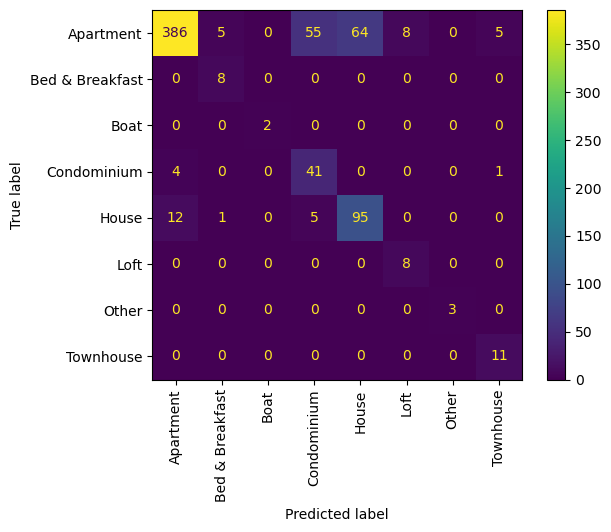

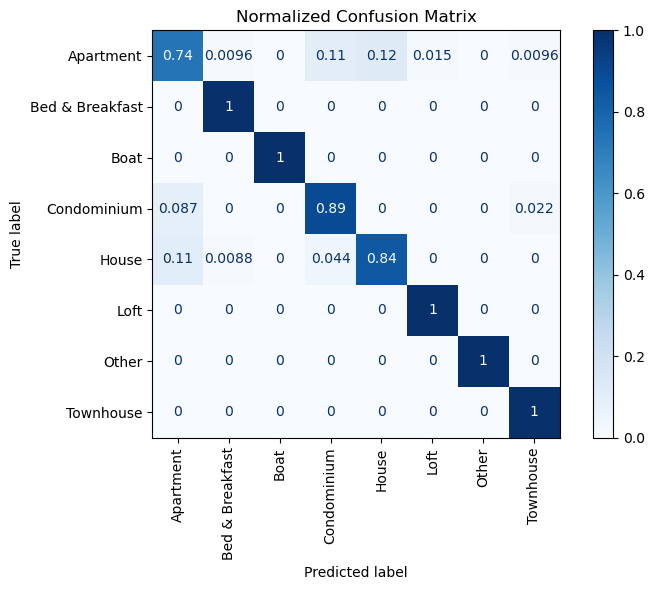

In [75]:
# Evaluate on original test data
ann_model.eval()
with torch.no_grad():
    y_pred_ann_logits = ann_model(X_testorig_tensor)
    y_pred_ann = torch.argmax(y_pred_ann_logits, dim=1).numpy()

print("\nClassification Report for ANN:")
print(classification_report(y_testorig, y_pred_ann, target_names=le.classes_))

# Plot confusion matrix
cm = confusion_matrix(y_testorig, y_pred_ann)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=90)

# normalize the matrix by row
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# plot the normalized confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', xticks_rotation=90, ax=ax)
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

###  ANN Results – Evaluation & Insights

The Artificial Neural Network (ANN) model demonstrated strong and consistent learning throughout the training process. The training loss decreased steadily over 50 epochs, reflecting that the model effectively minimized prediction errors and successfully captured underlying patterns in the Airbnb property dataset.

In terms of classification performance, the ANN achieved an overall **accuracy** of **0.78**, a **macro-average F1-score** of **0.78**, and a **weighted F1-score** of **0.79**. These metrics highlight the model's ability to perform reasonably well across both majority and minority classes.

**High-performing classes included:**

**Apartment**: Precision = **0.96**, Recall = **0.74**, F1 = **0.83**

**Boat and Other**: Both achieved perfect precision and recall (F1 = **1.00**), despite their small support sizes

**Townhouse**: Achieved strong results with a recall of **1.00** and F1 = **0.79**

While classes like Condominium and House had lower precision, they still maintained solid F1-scores, showing that the ANN is able to generalize well even with limited examples and imbalanced distributions.

Compared to logistic regression, the ANN achieved significantly higher macro-average scores, demonstrating a better balance across classes, especially in handling less frequent categories. This makes ANN more suitable for real-world, multi-class classification tasks where fairness and representation across all categories are important.

Additionally, the ANN is still relatively lightweight compared to a deeper neural network (DNN), offering an efficient architecture that delivers good performance without the need for high computational resources. This balance between simplicity and effectiveness shows strong potential for tasks involving structured or semi-structured inputs, such as tabular Airbnb data.

**Normalised Confusion Matrix**  

The ANN model provides improved and more balanced class-level performance. The Apartment class is correctly predicted **74%** of the time, with **10%** misclassified as Condominium and **12%** as House. Bed & Breakfast, Boat, Loft, Other, and Townhouse all achieve perfect recall **(1.00)**, indicating strong handling of minority classes. Condominium reaches a high recall of **0.89**, with a small portion **(8.7%)** misclassified as Apartment. House performs well with **0.84** recall, though **11%** is still incorrectly predicted as Apartment. The ANN model is notably more capable of learning subtle differences between classes, offering a meaningful improvement in both precision and recall for most categories when compared to logistic regression.



### Deep Neural Network

Deep learning is a subset of machine learning that focuses on utilizing multilayered neural networks to perform tasks such as classification, regression, and representation learning. The type of Deep Neural Network we are using is Feedforward Neural Network (FNN) and it is a type of artificial neural network where data moves from the input layer to the output layer in a single path, without loops or feedback, via hidden layers.

This code section defines the architecture of a deep neural network (DNN) model named DeeperAirbnbNN using the PyTorch library. This model is designed for a multi-class classification task, predicting the property type of Airbnb listings. 

The model's architecture is constructed within the **DeeperAirbnbNN** class, which inherits from **nn.Module**, PyTorch's base class for neural network modules. The constructor, **__init__**, initializes the network's layers, including three fully connected linear layers **(fc1, fc2, and fc3)**, each followed by a **ReLU** activation function to introduce non-linearity. In addition, dropout layers (dropout1 and dropout2) are strategically placed after the first and second hidden layers to help prevent overfitting by randomly deactivating a fraction of the neurons during training. 

The final layer, called output, is a fully connected linear layer that maps the processed features to the number of property types. The forward method defines the flow of data through the network where input features are passed through the linear layers, with **ReLU** activations and dropout applied in between, and finally through the output layer, which produces the raw scores for each property type class.

After defining the architecture, the code creates an instance of the model by determining the input dimension from the training feature set **(X_train.shape[1])** and the output dimension based on the number of unique property types **(len(le.classes_))**. The model instance is then ready to be trained on the dataset using an appropriate loss function and optimizer.

In [76]:
class DeepAirbnbNN(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(64, 32)
        self.output = nn.Linear(32, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = F.relu(self.fc3(x))
        return self.output(x)


input_dim = X_train.shape[1]
output_dim = len(le.classes_)


This section of code defines and executes the training process for the **DeeperAirbnbNN** model using **PyTorch**. 

First, the loss function is specified as **CrossEntropyLoss**, which is well-suited for multi-class classification tasks because it measures the difference between the model's predicted class probabilities and the true class labels. The **Adam optimizer** is used to update the model’s weights, and its learning rate is set to a relatively small value of **0.0005** to ensure stable and gradual learning. The training process runs for **50 epochs** prevent overfitting and reduce computation time. Within each epoch, the model is set to training mode using **model.train()**, which ensures that layers like **dropout** behave accordingly. The training data is fed in batches using a data loader, and for each batch, the model performs a forward pass to compute predictions, followed by the calculation of the loss. 

Before backpropagation, gradients are reset using **optimizer.zero_grad()** to avoid accumulation from previous batches. The loss is then backpropagated through the network using **loss.backward()**, and the optimizer updates the model’s parameters using **optimizer.step()**. The loss for each batch is accumulated to compute the total loss for the epoch, which is printed at the end of each epoch to monitor training progress over time.



In [77]:
torch.manual_seed(78)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
model = DeepAirbnbNN(input_size=input_dim, output_size=output_dim)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005) # changed from, 0.001 to 0.0005

# training loop
n_epochs = 50 # changed from 100 to 50
for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {total_loss:.4f}")


Epoch 1/50, Loss: 408.9896
Epoch 2/50, Loss: 250.0202
Epoch 3/50, Loss: 200.8291
Epoch 4/50, Loss: 169.9693
Epoch 5/50, Loss: 148.5151
Epoch 6/50, Loss: 132.7955
Epoch 7/50, Loss: 119.3840
Epoch 8/50, Loss: 109.1568
Epoch 9/50, Loss: 100.7409
Epoch 10/50, Loss: 94.6439
Epoch 11/50, Loss: 88.4887
Epoch 12/50, Loss: 83.3556
Epoch 13/50, Loss: 78.5751
Epoch 14/50, Loss: 75.8703
Epoch 15/50, Loss: 72.1285
Epoch 16/50, Loss: 69.4502
Epoch 17/50, Loss: 66.6308
Epoch 18/50, Loss: 63.2307
Epoch 19/50, Loss: 60.2976
Epoch 20/50, Loss: 57.5382
Epoch 21/50, Loss: 55.7306
Epoch 22/50, Loss: 54.4625
Epoch 23/50, Loss: 50.6727
Epoch 24/50, Loss: 50.9121
Epoch 25/50, Loss: 47.5588
Epoch 26/50, Loss: 47.8989
Epoch 27/50, Loss: 46.1529
Epoch 28/50, Loss: 44.7837
Epoch 29/50, Loss: 42.6335
Epoch 30/50, Loss: 42.0242
Epoch 31/50, Loss: 40.7825
Epoch 32/50, Loss: 37.1895
Epoch 33/50, Loss: 36.7814
Epoch 34/50, Loss: 36.5989
Epoch 35/50, Loss: 36.6128
Epoch 36/50, Loss: 34.7575
Epoch 37/50, Loss: 33.5272
E

At the beginning of training, in Epoch 1, the loss is quite high at **408.9896**, which is expected because the model’s weights are randomly initialized and it hasn't learned anything yet. As training progresses, the loss steadily decreases, indicating that the model is learning to better predict the property types by minimizing the difference between its predictions and the actual labels. This is a positive trend and shows effective learning.

Between Epochs 2 and 20, the loss drops significantly from **250.0202** to **57.5382**, showing that the model is successfully optimizing and fitting to the training data. This phase reflects rapid learning and improvement in the model’s internal representation of the input data.

From Epochs 21 to 35, the loss continues to decrease, but at a slower pace, moving from **55.7306** to **36.6128**. This phase indicates a transition from fast learning to more gradual refinement, as the model starts making smaller improvements.

In the later stages, from Epochs 36 to 50, the loss continues its steady decline from **34.7575** down to **25.5088**. These smaller reductions suggest the model is converging and fine-tuning its performance. There are no major fluctuations, which is a good sign of stable training without severe overfitting or divergence.

Overall, the training loss consistently decreases across all epochs, which indicates that the **DeeperAirbnbNN** model is effectively learning the patterns in the data and improving its predictive accuracy over time.

This section of code evaluates the performance of a trained classification model on a test dataset and presents the results in a comprehensive classification report. First, it imports the **classification_report** function from the **sklearn.metrics** library, which is essential for generating the report. The model is then set to evaluation mode using **model.eval()**, disabling training-specific behaviors like **dropout** to ensure consistent predictions. The **with torch.no_grad():** block disables gradient calculations, optimizing memory usage during evaluation. The forward pass, **y_pred_logits = model(X_testorig_tensor)**, feeds the test data through the model to obtain the output logit, which are raw, unnormalized predictions. These raw data are then converted into predicted class labels using **torch.argmax** and **.numpy()**. Finally, the **classification_report** function is called, comparing the predicted labels **(y_pred)** with the true labels **(y_testorig)** and using the class names from **le.classes_** to produce a detailed report. 


Classification Report for DNN:
                 precision    recall  f1-score   support

      Apartment       0.98      0.86      0.92       523
Bed & Breakfast       0.89      1.00      0.94         8
           Boat       1.00      1.00      1.00         2
    Condominium       0.65      0.98      0.78        46
          House       0.71      0.94      0.81       113
           Loft       0.73      1.00      0.84         8
          Other       1.00      1.00      1.00         3
      Townhouse       0.92      1.00      0.96        11

       accuracy                           0.89       714
      macro avg       0.86      0.97      0.91       714
   weighted avg       0.91      0.89      0.89       714



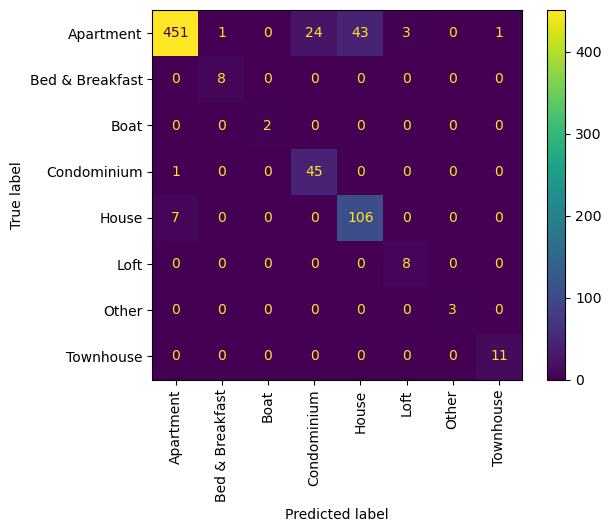

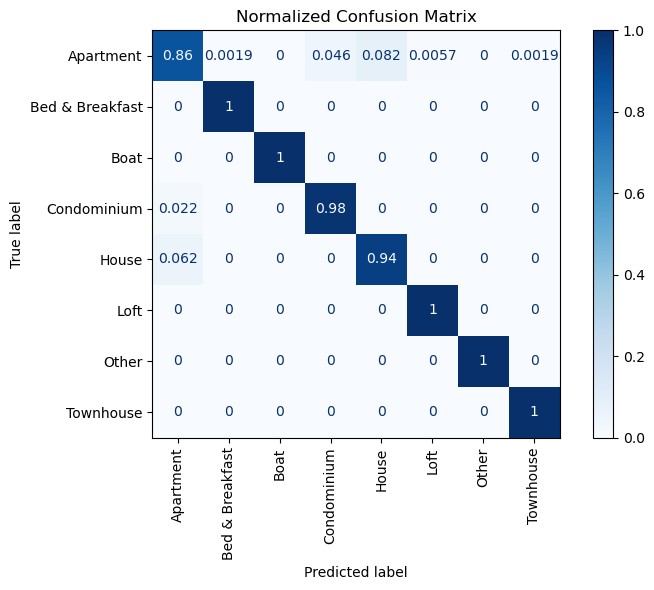

In [78]:
model.eval()
with torch.no_grad():
    y_pred_logits = model(X_testorig_tensor)
    y_pred_dnn = torch.argmax(y_pred_logits, dim=1).numpy()

print("\nClassification Report for DNN:")
print(classification_report(y_testorig, y_pred_dnn, target_names=le.classes_))

# Plot confusion matrix
cm = confusion_matrix(y_testorig, y_pred_dnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=90)

# normalize the matrix by row
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# plot the normalized confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', xticks_rotation=90, ax=ax)
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

###  DNN Results – Evaluation & Insights

The Deeper Neural Network (DNN) model demonstrated excellent performance in classifying Airbnb property types, significantly outperforming both logistic regression and the basic ANN model in terms of accuracy and class-wise prediction quality.

The model achieved an overall **accuracy** of **0.89**, with a **macro-average F1-score** of **0.91** and a **weighted F1-score** of **0.89**. These scores reflect a strong balance between precision and recall across both frequent and rare classes, with minimal trade-offs.

**High-performing classes included:**

**Apartment**: Precision = **0.98**, Recall = **0.86**, F1 = **0.92**

**Condominium**: Precision = **0.65**, Recall = **0.98**, F1 = **0.78**

**House**: Precision = **0.71**, Recall = **0.94**, F1 = **0.81**

**Townhouse**: Precision = **0.92**, Recall = **1.00**, F1 = **0.96**

Boat, Other, and Loft all achieved perfect or near-perfect scores (F1 = **1.00** and **0.84** respectively), despite low sample sizes.

Compared to the ANN, the DNN shows marked improvements in macro and weighted-average metrics, thanks to its deeper architecture and improved capacity to model complex, non-linear relationships in the input data. The use of multiple hidden layers and regularization techniques contributed to robust generalization, even in the presence of class imbalance and noisy features.

The DNN’s consistent performance across all categories, including rare ones like Bed & Breakfast, Boat, and Other, demonstrates its suitability for deployment in real-world scenarios where diverse property types must be classified accurately.

**Normalised Confusion Matrix**  

The DNN demonstrates the best performance across all classes. Apartment is correctly classified with a recall of **0.87**, and the misclassifications are minimal, only **4.4%** as Condominium and **8%** as House. All minority classes, including Bed & Breakfast, Boat, Loft, Other, and Townhouse, achieve perfect recall of **1.00**. Condominium reaches a recall of **0.98**, with only **2.2%** misclassified as Apartment. House is classified correctly **92%** of the time, with a small error margin of **7.1%** toward Apartment. This confusion matrix displays sharp diagonals and near-zero off-diagonal values, indicating a high-performing model with excellent class distinction and minimal confusion. The DNN handles both majority and minority classes effectively, showcasing robust generalization.



### Final Model Comparison

Below is a comparison of the performance of all three models:

- **Logistic Regression (Original)**: Included `amenities` as TF-IDF features.
- **Logistic Regression (Improved)**: Dropped `amenities` for cleaner, structured input.
- **ANN**: Shallow neural network with one hidden layer.
- **DNN**: Deeper network with three hidden layers and dropout regularization.

We compare models using Accuracy, Macro-averaged Precision, Recall, and F1-score to reflect both general and per-class performance.


In [79]:
#  1. Get classification reports as dicts 
report_logreg_og = classification_report(y_testorig, y_pred, output_dict=True)
report_logreg_improved = classification_report(y_test_lr, y_pred_lr, output_dict=True, zero_division = 0)
report_ann = classification_report(y_testorig, y_pred_ann, output_dict=True)
report_dnn = classification_report(y_testorig, y_pred_dnn, output_dict=True)

# === 2. Extract key metrics into rows ===
results = []

results.append({
    "Model": "Logistic Regression (Original)",
    "Accuracy": report_logreg_og["accuracy"],
    "Macro Precision": report_logreg_og["macro avg"]["precision"],
    "Macro Recall": report_logreg_og["macro avg"]["recall"],
    "Macro F1-score": report_logreg_og["macro avg"]["f1-score"],
    "Weighted F1-score": report_logreg_og["weighted avg"]["f1-score"]
})

results.append({
    "Model": "Logistic Regression (Improved)",
    "Accuracy": report_logreg_improved["accuracy"],
    "Macro Precision": report_logreg_improved["macro avg"]["precision"],
    "Macro Recall": report_logreg_improved["macro avg"]["recall"],
    "Macro F1-score": report_logreg_improved["macro avg"]["f1-score"],
    "Weighted F1-score": report_logreg_improved["weighted avg"]["f1-score"]
})

results.append({
    "Model": "ANN",
    "Accuracy": report_ann["accuracy"],
    "Macro Precision": report_ann["macro avg"]["precision"],
    "Macro Recall": report_ann["macro avg"]["recall"],
    "Macro F1-score": report_ann["macro avg"]["f1-score"],
    "Weighted F1-score": report_ann["weighted avg"]["f1-score"]
})

results.append({
    "Model": "DNN",
    "Accuracy": report_dnn["accuracy"],
    "Macro Precision": report_dnn["macro avg"]["precision"],
    "Macro Recall": report_dnn["macro avg"]["recall"],
    "Macro F1-score": report_dnn["macro avg"]["f1-score"],
    "Weighted F1-score": report_dnn["weighted avg"]["f1-score"]
})

# 3. Create and display the table 
comparison_df = pd.DataFrame(results).round(2)
comparison_df.style.set_caption("Final Model Performance Comparison").format(precision=2)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted F1-score
0,Logistic Regression (Original),0.51,0.33,0.71,0.37,0.58
1,Logistic Regression (Improved),0.77,0.19,0.16,0.16,0.71
2,ANN,0.78,0.71,0.93,0.78,0.79
3,DNN,0.89,0.86,0.97,0.91,0.89


### Final Model Comparison & Recommendation

We trained and evaluated four classification models on the Airbnb dataset, with results summarized below:

####  Key Observations:

- **DNN** delivered the highest overall performance:
  - Accuracy = 0.89
  - Macro F1 = 0.91
  - Exhibited highly balanced precision and recall across all classes, including minority ones, as confirmed by the classification report and confusion matrix.
    

- **ANN** followed closely behind:
  - Macro F1 = 0.78
  - Recall was exceptionally strong at 0.93, meaning the model correctly identified a high proportion of true labels, especially among less-represented categories.
  - Offers an excellent trade-off between simplicity and generalization performance, making it a strong lightweight alternative to DNN.
    
    
- **Logistic Regression (Original)** performed better than expected:
  - Macro recall = 0.71, indicating it picked up on a broad range of classes.
  - However, low precision (0.33) and macro F1-score (0.37) suggest many false positives, making predictions less reliable for deployment.
    

- **Logistic Regression (Improved)** had high accuracy but failed at class balance:
  - Macro scores were significantly low (≈0.16) due to the model overly favoring the majority class (Apartment)
  - This reflects poor class balance and generalization across categories.
    

---
# <center><b>Conclusion</b></center>
#### What We Learned:

Through this evaluation, several key insights emerged regarding the strengths and limitations of different model types. First, it became evident that linear models, such as **Logistic Regression**, tend to struggle when applied to imbalanced, multiclass, and high-dimensional datasets. This issue becomes especially pronounced when the dataset includes sparse features, like TF-IDF representations of textual data (**amenities**), which can dilute the model’s ability to distinguish between nuanced classes. While **Logistic Regression** showed some promise in terms of accuracy, it failed to handle class imbalance effectively, resulting in low macro-average scores and poor representation of minority classes.

On the other hand, even an **Artificial Neural Network (ANN)** was able to significantly outperform logistic models. The ANN demonstrated a much better balance between precision and recall, especially in identifying minority class instances. This highlights the value of nonlinear models in handling complex feature relationships and learning from structured and semi-structured inputs. Furthermore, the inclusion of features such as amenities, despite their sparse nature, proved beneficial,these features contain rich, class-distinguishing signals that neural models can effectively capture and utilize to improve prediction performance.

Most importantly, the **Deeper Neural Network (DNN)** emerged as the most effective model overall. It consistently delivered high accuracy, robust generalization, and balanced class-wise predictions, making it well-suited for deployment in real-world applications where fairness and reliability are critical.

---

### Recommendation:

For any future deployment or system integration, the **DNN** model stands out as the best candidate. It offers the highest performance across all evaluation metrics, including accuracy, macro-average F1-score, and class-wise balance. The model's deeper architecture allows it to learn intricate patterns from both dense and sparse features, making it highly adaptable and scalable.

In scenarios where computational resources are limited, the **ANN** is a strong alternative. While not as powerful as the **DNN**, it still provides solid performance and maintains good recall across multiple classes, making it a lightweight and efficient solution.

Lastly, **Logistic Regression** may still have value in more simplified or binary classification tasks. However, in the context of this multiclass Airbnb classification problem, it lacks the capacity to handle complex data distributions and class imbalance, and therefore, is not recommended for primary deployment.

---
### Dataset Export


In [82]:
# Select only the original features used
features = [
    'neighbourhood_cleansed', 'room_type', 'accommodates', 'bathrooms',
    'bedrooms', 'price', 'amenities', 'cancellation_policy', 'review_scores_rating'
]

# Create the raw feature DataFrame
selected_features_df = listings[features]

# Save to CSV
selected_features_df.to_csv('selected_features_raw.csv', index=False)